# iTAPAS vs Frank-Wolfe 比較実験

利用者均衡 (UE) 配分における iTAPAS と Frank-Wolfe 法の比較。

1. **Sioux Falls ネットワーク**: 収束速度・解の精度を比較
2. **Grid ネットワーク**: ネットワーク規模に対するスケーラビリティを比較

In [1]:
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# 両ソルバーと共通モジュールの読み込み
from network import Network
from cost_function import bpr_cost, bpr_cost_derivative, bpr_cost_integral
from itapas import ITAPAS

sys.path.insert(0, "../frank-wolfe")
from frank_wolfe import FrankWolfe

# Matplotlib スタイル設定 (MatplotlibStyleRule.md 準拠)
COLORS = {
    "red":    "#FF4B00",
    "blue":   "#005AFF",
    "green":  "#03AF7A",
    "cyan":   "#4DC4FF",
    "orange": "#F6AA00",
    "yellow": "#FFF100",
    "purple": "#990099",
    "gray":   "#84919E",
    "black":  "#000000",
}
COLOR_CYCLE = [
    COLORS["red"], COLORS["blue"], COLORS["green"],
    COLORS["cyan"], COLORS["orange"], COLORS["purple"],
    COLORS["gray"], COLORS["black"],
]

mpl.rcParams.update({
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "IPAexGothic"],
    "font.size":          10,
    "axes.labelsize":     12,
    "axes.titlesize":     12,
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    10,
    "mathtext.fontset":   "stixsans",
    "figure.figsize":     (3.5, 2.625),
    "figure.dpi":         150,
    "savefig.dpi":        600,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "lines.linewidth":    1.5,
    "lines.markersize":   6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "xtick.direction":    "in",
    "ytick.direction":    "in",
    "xtick.major.size":   4,
    "ytick.major.size":   4,
    "xtick.minor.size":   2,
    "ytick.minor.size":   2,
    "axes.grid":          False,
    "axes.prop_cycle":    mpl.cycler(color=COLOR_CYCLE),
    "legend.frameon":     False,
    "legend.numpoints":   1,
    "legend.scatterpoints": 1,
})

## 1. Sioux Falls ネットワークでの比較

24ノード・76リンクの標準的なテストネットワーク。同一の収束閾値 (rel_gap < 1e-3) で両手法を実行し、計算時間と収束過程を比較する。

In [2]:
# Sioux Falls データ読み込み
data_dir = "data/SiouxFalls"
sf_net = Network(f"{data_dir}/node.csv", f"{data_dir}/link.csv", f"{data_dir}/demand.csv")
print(f"Sioux Falls: {sf_net.num_nodes}ノード, {sf_net.num_links}リンク, {len(sf_net.demand)} OD対")

GAP_THRESHOLD = 1e-3
MAX_ITER_FW = 300
MAX_ITER_ITAPAS = 100

Sioux Falls: 24ノード, 76リンク, 528 OD対


In [3]:
# 十分なイテレーションで両手法を実行し、収束ログを取得
# (同一精度到達時間の比較に使用)

# --- Frank-Wolfe (300 iter, 閾値なし) ---
print("=== Frank-Wolfe ===")
fw_solver = FrankWolfe(sf_net, bpr_cost, bpr_cost_derivative, bpr_cost_integral)
fw_flow, fw_log = fw_solver.solve(max_iter=300, gap_threshold=1e-10, verbose=False)
print(f"  イテレーション数: {fw_log[-1]['iter']}")
print(f"  計算時間:         {fw_log[-1]['time']:.2f}s")
print(f"  最終 rel_gap:     {fw_log[-1]['rel_gap']:.6e}")

# --- iTAPAS (100 iter, 閾値なし, デフォルトパラメータ) ---
print("\n=== iTAPAS ===")
itapas_solver = ITAPAS(sf_net, bpr_cost, bpr_cost_derivative, bpr_cost_integral)
it_flow, it_log = itapas_solver.solve(max_iter=100, gap_threshold=1e-10, verbose=False)
print(f"  イテレーション数: {it_log[-1]['iter']}")
print(f"  計算時間:         {it_log[-1]['time']:.2f}s")
print(f"  最終 rel_gap:     {it_log[-1]['rel_gap']:.6e}")

=== Frank-Wolfe ===


  イテレーション数: 300
  計算時間:         1.88s
  最終 rel_gap:     4.744169e-04

=== iTAPAS ===


  イテレーション数: 21
  計算時間:         0.25s
  最終 rel_gap:     5.142638e-11


### 1.1 収束過程の比較

横軸を計算時間 (秒) として、相対双対ギャップの推移を比較する。

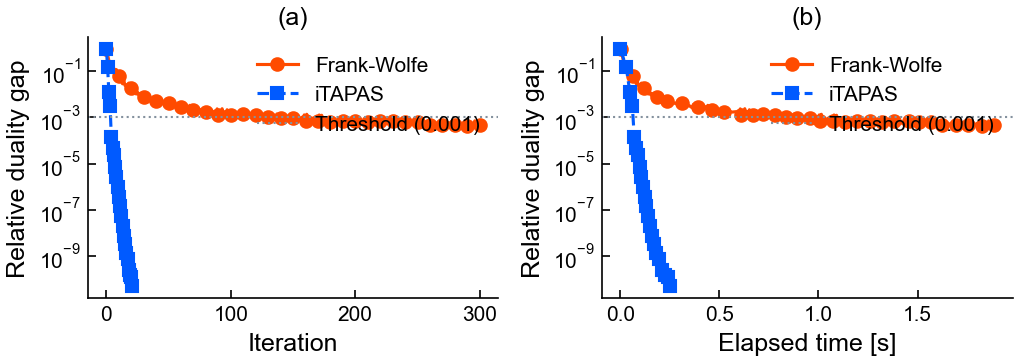

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.625))

# (a) イテレーション vs rel_gap
ax = axes[0]
ax.semilogy([e['iter'] for e in fw_log], [e['rel_gap'] for e in fw_log],
            '-o', color=COLORS["red"], markevery=10, label='Frank-Wolfe')
ax.semilogy([e['iter'] for e in it_log], [e['rel_gap'] for e in it_log],
            '--s', color=COLORS["blue"], label='iTAPAS')
ax.axhline(y=GAP_THRESHOLD, color=COLORS["gray"], linestyle=':', linewidth=1.0,
           label=f'Threshold ({GAP_THRESHOLD})')
ax.set_xlabel("Iteration")
ax.set_ylabel("Relative duality gap")
ax.set_title("(a)")
ax.legend(loc='upper right')

# (b) 計算時間 vs rel_gap
ax = axes[1]
ax.semilogy([e['time'] for e in fw_log], [e['rel_gap'] for e in fw_log],
            '-o', color=COLORS["red"], markevery=10, label='Frank-Wolfe')
ax.semilogy([e['time'] for e in it_log], [e['rel_gap'] for e in it_log],
            '--s', color=COLORS["blue"], label='iTAPAS')
ax.axhline(y=GAP_THRESHOLD, color=COLORS["gray"], linestyle=':', linewidth=1.0,
           label=f'Threshold ({GAP_THRESHOLD})')
ax.set_xlabel("Elapsed time [s]")
ax.set_ylabel("Relative duality gap")
ax.set_title("(b)")
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 1.2 同一精度到達時間の比較

各目標 rel_gap に最初に到達した計算時間を比較する。同じ精度を達成するのに、どちらが何倍速いかを示す。

In [5]:
def time_to_gap(log, target_gap):
    """ログから目標 rel_gap に最初に到達した時刻を返す (到達しなければ None)"""
    for entry in log:
        if entry['rel_gap'] <= target_gap:
            return entry['time']
    return None

# 比較する目標精度レベル
targets = [1e-1, 5e-2, 2e-2, 1e-2, 5e-3, 2e-3, 1e-3, 5e-4]

rows = []
for tg in targets:
    fw_t = time_to_gap(fw_log, tg)
    it_t = time_to_gap(it_log, tg)
    speedup = fw_t / it_t if (fw_t is not None and it_t is not None and it_t > 0) else None
    rows.append({'target_gap': tg, 'FW_time': fw_t, 'iTAPAS_time': it_t, 'speedup': speedup})

df_ttg = pd.DataFrame(rows)

# テーブル表示
print("目標 rel_gap に到達するまでの計算時間 [s]")
print("-" * 60)
print(f"{'target gap':>12s} {'FW':>10s} {'iTAPAS':>10s} {'速度比':>10s}")
for _, r in df_ttg.iterrows():
    fw_s = f"{r['FW_time']:.3f}" if r['FW_time'] is not None else "未到達"
    it_s = f"{r['iTAPAS_time']:.3f}" if r['iTAPAS_time'] is not None else "未到達"
    sp_s = f"{r['speedup']:.1f}x" if r['speedup'] is not None else "-"
    print(f"{r['target_gap']:>12.0e} {fw_s:>10s} {it_s:>10s} {sp_s:>10s}")

目標 rel_gap に到達するまでの計算時間 [s]
------------------------------------------------------------
  target gap         FW     iTAPAS        速度比
       1e-01      0.047      0.049       1.0x
       5e-02      0.071      0.049       1.5x
       2e-02      0.103      0.049       2.1x
       1e-02      0.155      0.062       2.5x
       5e-03      0.226      0.062       3.7x
       2e-03      0.508      0.071       7.1x
       1e-03      0.792      0.071      11.1x
       5e-04      1.397      0.071      19.6x


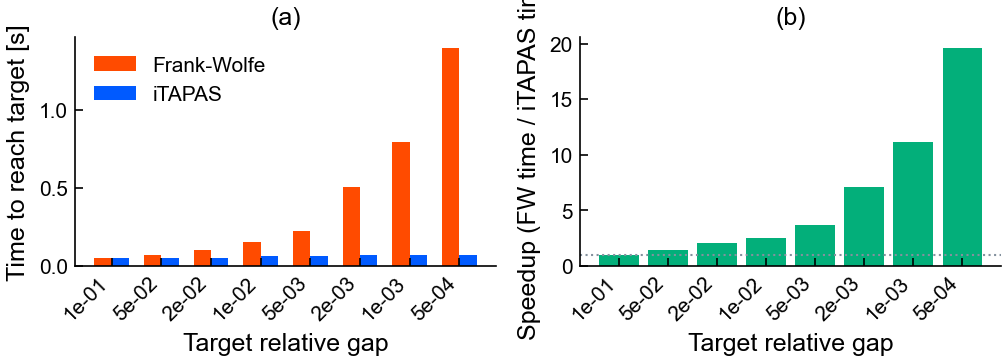

In [6]:
# 同一精度到達時間の棒グラフ
# 両手法とも到達した精度レベルのみプロット
df_plot = df_ttg.dropna(subset=['FW_time', 'iTAPAS_time']).copy()

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.625))

# (a) 到達時間の比較 (対数スケール棒グラフ)
ax = axes[0]
x = np.arange(len(df_plot))
w = 0.35
ax.bar(x - w/2, df_plot['FW_time'], w, color=COLORS["red"], label='Frank-Wolfe')
ax.bar(x + w/2, df_plot['iTAPAS_time'], w, color=COLORS["blue"], label='iTAPAS')
ax.set_xticks(x)
ax.set_xticklabels([f"{g:.0e}" for g in df_plot['target_gap']], rotation=45, ha='right')
ax.set_xlabel("Target relative gap")
ax.set_ylabel("Time to reach target [s]")
ax.set_title("(a)")
ax.set_ylim(bottom=0)
ax.legend(loc='upper left')

# (b) 速度比 (iTAPAS が何倍速いか)
ax = axes[1]
ax.bar(x, df_plot['speedup'], color=COLORS["green"])
ax.set_xticks(x)
ax.set_xticklabels([f"{g:.0e}" for g in df_plot['target_gap']], rotation=45, ha='right')
ax.set_xlabel("Target relative gap")
ax.set_ylabel("Speedup (FW time / iTAPAS time)")
ax.set_title("(b)")
ax.axhline(y=1.0, color=COLORS["gray"], linestyle=':', linewidth=1.0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

### 1.3 均衡条件の達成度

均衡状態では、使用経路のコストが最短経路コストに一致する (Wardrop の第一原則)。
各リンクの **縮約コスト** (reduced cost) $rc_a = d_i - d_j + t_a(f_a)$ を計算し、
フローが正のリンクでの縮約コスト分布を比較する。均衡に近いほど $rc_a \approx 0$ となる。

In [7]:
def compute_reduced_costs(net, link_flow, solver_instance):
    """各起点について、フローが正のリンクの縮約コストを計算"""
    link_cost = bpr_cost(link_flow, net.link_fftt, net.link_capacity,
                         net.link_alpha, net.link_beta)
    all_rc = []
    for r in net.origins:
        dist, _ = solver_instance._shortest_path(link_cost, r)
        for e in range(net.num_links):
            if link_flow[e] > 1.0:  # フローが正のリンクのみ
                i = net.link_from[e]
                j = net.link_to[e]
                rc = dist[i] - dist[j] + link_cost[e]
                if rc > 1e-10:
                    all_rc.append(rc)
    return np.array(all_rc)

# 縮約コストの計算
fw_rc = compute_reduced_costs(sf_net, fw_flow, fw_solver)
it_rc = compute_reduced_costs(sf_net, it_flow, itapas_solver)

print("=== 均衡条件の達成度 (フロー正リンクの縮約コスト) ===")
print(f"{'':20s} {'Frank-Wolfe':>15s} {'iTAPAS':>15s}")
print(f"{'正の縮約コスト数':20s} {len(fw_rc):>15d} {len(it_rc):>15d}")
print(f"{'平均':20s} {fw_rc.mean():>15.4f} {it_rc.mean():>15.4f}")
print(f"{'最大':20s} {fw_rc.max():>15.4f} {it_rc.max():>15.4f}")
print(f"{'中央値':20s} {np.median(fw_rc):>15.4f} {np.median(it_rc):>15.4f}")

=== 均衡条件の達成度 (フロー正リンクの縮約コスト) ===
                         Frank-Wolfe          iTAPAS
正の縮約コスト数                        1272            1250
平均                           12.6418         12.8687
最大                           40.2849         40.3211
中央値                          10.4742         11.0536


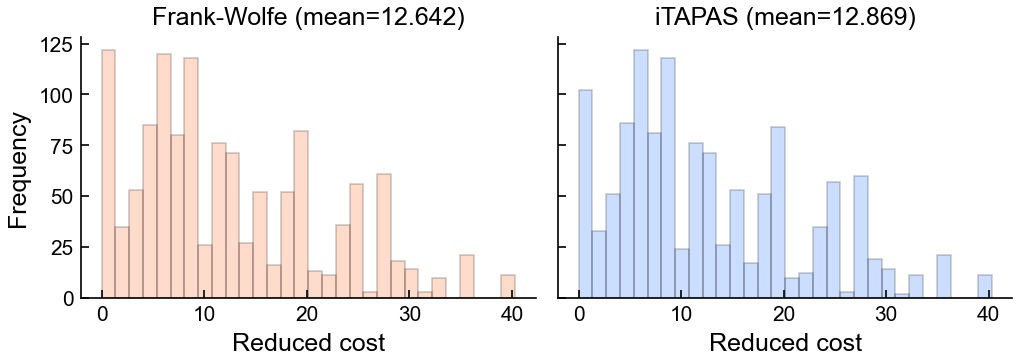

In [8]:
# 縮約コスト分布のヒストグラム
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.625), sharey=True)

axes[0].hist(fw_rc, bins=30, edgecolor=COLORS["black"], alpha=0.2,
             color=COLORS["red"], linewidth=0.8)
axes[0].set_xlabel("Reduced cost")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Frank-Wolfe (mean={fw_rc.mean():.3f})")
axes[0].set_ylim(bottom=0)

axes[1].hist(it_rc, bins=30, edgecolor=COLORS["black"], alpha=0.2,
             color=COLORS["blue"], linewidth=0.8)
axes[1].set_xlabel("Reduced cost")
axes[1].set_title(f"iTAPAS (mean={it_rc.mean():.3f})")
axes[1].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

### 1.4 リンクフローの比較

両手法で得られたリンクフローの散布図。対角線に近いほど解が一致している。

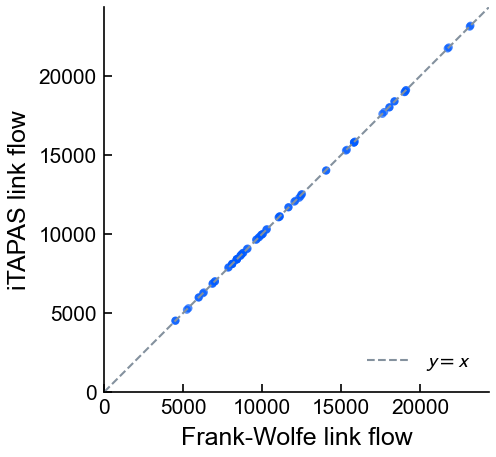

リンクフロー差: 平均=14.2, 最大=56.9, 相対RMSE=0.17%


In [9]:
fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.scatter(fw_flow, it_flow, s=15, alpha=0.7, color=COLORS["blue"], edgecolors='none')
lim = max(fw_flow.max(), it_flow.max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color=COLORS["gray"], linewidth=1.0, label='$y = x$')
ax.set_xlabel("Frank-Wolfe link flow")
ax.set_ylabel("iTAPAS link flow")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect('equal')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# 差の統計
diff = np.abs(fw_flow - it_flow)
print(f"リンクフロー差: 平均={diff.mean():.1f}, 最大={diff.max():.1f}, "
      f"相対RMSE={np.sqrt(np.mean((fw_flow - it_flow)**2)) / np.mean(fw_flow) * 100:.2f}%")

## 2. Grid ネットワーク: 同一精度到達時間の比較

$N \times N$ の格子ネットワークで、同一の rel_gap に到達するまでの計算時間を比較する。
両手法を十分なイテレーションで走らせ、各目標精度への到達時間を収束ログから抽出する。

**シナリオ構成** (ネットワーク規模 $\times$ 需要規模):
- **低需要**: 9ゾーン固定 (72 OD対)
- **高需要**: 辺上全ノードがゾーン (OD対数はグリッドサイズに依存)

In [10]:
import os, tempfile
from collections import defaultdict

class GridNetwork:
    """N x N のグリッドネットワークを動的に生成する"""

    def __init__(self, grid_size, num_zones=None, demand_per_od=100):
        """
        Parameters
        ----------
        grid_size : int
            グリッドの1辺のノード数
        num_zones : int or None
            ゾーン数 (None の場合は辺上のノードを使用)
        demand_per_od : float
            各OD対の需要量
        """
        N = grid_size
        self.num_nodes = N * N
        self.node_ids = list(range(self.num_nodes))
        self.node_id_to_idx = {i: i for i in range(self.num_nodes)}
        self.idx_to_node_id = {i: i for i in range(self.num_nodes)}

        # リンク生成 (双方向)
        link_from_list = []
        link_to_list = []
        for r in range(N):
            for c in range(N):
                node = r * N + c
                # 右方向
                if c + 1 < N:
                    link_from_list.append(node)
                    link_to_list.append(node + 1)
                    link_from_list.append(node + 1)
                    link_to_list.append(node)
                # 下方向
                if r + 1 < N:
                    link_from_list.append(node)
                    link_to_list.append(node + N)
                    link_from_list.append(node + N)
                    link_to_list.append(node)

        self.num_links = len(link_from_list)
        self.link_from = np.array(link_from_list, dtype=int)
        self.link_to = np.array(link_to_list, dtype=int)

        # BPR パラメータ
        self.link_capacity = np.full(self.num_links, 1000.0)
        self.link_fftt = np.full(self.num_links, 1.0)
        self.link_alpha = np.full(self.num_links, 0.15)
        self.link_beta = np.full(self.num_links, 4.0)

        # ゾーン (辺上のノードを起終点とする)
        if num_zones is None:
            zones = set()
            for r in range(N):
                for c in range(N):
                    if r == 0 or r == N - 1 or c == 0 or c == N - 1:
                        zones.add(r * N + c)
            zones = sorted(zones)
        else:
            # 均等に配置
            step = max(1, N // int(np.sqrt(num_zones)))
            zones = []
            for r in range(0, N, step):
                for c in range(0, N, step):
                    zones.append(r * N + c)
            zones = zones[:num_zones]

        self.origins = zones

        # 需要: 全ゾーン間 (自己需要除く)
        self.demand = {}
        for o in zones:
            for d in zones:
                if o != d:
                    self.demand[(o, d)] = demand_per_od

        # 隣接リスト
        self.out_links = defaultdict(list)
        self.in_links = defaultdict(list)
        for e in range(self.num_links):
            self.out_links[self.link_from[e]].append(e)
            self.in_links[self.link_to[e]].append(e)

    def summary(self):
        return (f"{int(np.sqrt(self.num_nodes))}x{int(np.sqrt(self.num_nodes))} grid: "
                f"{self.num_nodes}ノード, {self.num_links}リンク, "
                f"{len(self.origins)}ゾーン, {len(self.demand)} OD対")

# テスト
test_grid = GridNetwork(5)
print(test_grid.summary())

5x5 grid: 25ノード, 80リンク, 16ゾーン, 240 OD対


In [11]:
# 全シナリオで両手法を十分なイテレーションで走らせ、収束ログを保存
scenarios = [
    # (label, grid_size, num_zones, demand_per_od)
    ("5x5 low",   5,  9,    200),
    ("10x10 low", 10, 9,    200),
    ("15x15 low", 15, 9,    200),
    ("5x5 high",  5,  None, 50),
    ("8x8 high",  8,  None, 50),
    ("10x10 high",10, None, 50),
    ("12x12 high",12, None, 50),
]

FW_MAX = 300
IT_MAX = 50
TIME_LIM = 120

all_logs = {}  # {label: {'fw': log, 'it': log, 'info': {...}}}

for label, gs, nz, dpod in scenarios:
    gnet = GridNetwork(gs, num_zones=nz, demand_per_od=dpod)
    n_zones = len(gnet.origins)
    n_od = len(gnet.demand)
    print(f"{label}: {gnet.num_nodes}N, {gnet.num_links}L, {n_zones}Z, {n_od}OD")

    fw = FrankWolfe(gnet, bpr_cost, bpr_cost_derivative, bpr_cost_integral)
    _, fw_l = fw.solve(max_iter=FW_MAX, gap_threshold=1e-10, verbose=False)

    it = ITAPAS(gnet, bpr_cost, bpr_cost_derivative, bpr_cost_integral)
    _, it_l = it.solve(max_iter=IT_MAX, gap_threshold=1e-10,
                        time_limit=TIME_LIM, verbose=False)

    print(f"  FW:     {fw_l[-1]['time']:.2f}s, gap={fw_l[-1]['rel_gap']:.2e}")
    print(f"  iTAPAS: {it_l[-1]['time']:.2f}s, gap={it_l[-1]['rel_gap']:.2e}")

    all_logs[label] = {
        'fw': fw_l, 'it': it_l,
        'info': {'nodes': gnet.num_nodes, 'links': gnet.num_links,
                 'zones': n_zones, 'od_pairs': n_od}
    }

5x5 low: 25N, 80L, 9Z, 72OD


  FW:     0.56s, gap=2.22e-04
  iTAPAS: 0.05s, gap=8.87e-11
10x10 low: 100N, 360L, 9Z, 72OD


  FW:     0.67s, gap=1.21e-04
  iTAPAS: 0.46s, gap=1.70e-06
15x15 low: 225N, 840L, 9Z, 72OD


  FW:     0.83s, gap=3.61e-05
  iTAPAS: 1.04s, gap=9.92e-07
5x5 high: 25N, 80L, 16Z, 240OD


  FW:     1.15s, gap=1.14e-04
  iTAPAS: 0.29s, gap=9.56e-11
8x8 high: 64N, 224L, 28Z, 756OD


  FW:     3.20s, gap=1.96e-03
  iTAPAS: 2.85s, gap=7.75e-09
10x10 high: 100N, 360L, 36Z, 1260OD


  FW:     5.23s, gap=4.81e-03
  iTAPAS: 4.91s, gap=6.17e-06
12x12 high: 144N, 528L, 44Z, 1892OD


  FW:     7.89s, gap=8.05e-03
  iTAPAS: 8.63s, gap=7.80e-06


### 2.1 同一精度到達時間テーブル

各シナリオ・各目標精度について、FW と iTAPAS の到達時間と速度比を表示する。

In [12]:
target_gaps = [1e-1, 5e-2, 1e-2, 5e-3, 2e-3, 1e-3]

rows = []
for label, data in all_logs.items():
    info = data['info']
    for tg in target_gaps:
        fw_t = time_to_gap(data['fw'], tg)
        it_t = time_to_gap(data['it'], tg)
        sp = fw_t / it_t if (fw_t and it_t and it_t > 0) else None
        rows.append({
            'scenario': label,
            'nodes': info['nodes'],
            'OD pairs': info['od_pairs'],
            'target_gap': tg,
            'FW [s]': fw_t,
            'iTAPAS [s]': it_t,
            'speedup': sp,
        })

df_grid_ttg = pd.DataFrame(rows)

# シナリオごとにテーブル表示
for label in all_logs:
    info = all_logs[label]['info']
    sub = df_grid_ttg[df_grid_ttg['scenario'] == label]
    print(f"\n{label} ({info['nodes']}N, {info['zones']}Z, {info['od_pairs']}OD)")
    print(f"  {'target':>10s} {'FW [s]':>10s} {'iTAPAS [s]':>10s} {'speedup':>10s}")
    for _, r in sub.iterrows():
        fw_s = f"{r['FW [s]']:.3f}" if r['FW [s]'] is not None else "-"
        it_s = f"{r['iTAPAS [s]']:.3f}" if r['iTAPAS [s]'] is not None else "-"
        sp_s = f"{r['speedup']:.1f}x" if r['speedup'] is not None else "-"
        print(f"  {r['target_gap']:>10.0e} {fw_s:>10s} {it_s:>10s} {sp_s:>10s}")


5x5 low (25N, 9Z, 72OD)
      target     FW [s] iTAPAS [s]    speedup
       1e-01      0.004      0.003       1.5x
       5e-02      0.006      0.003       2.2x
       1e-02      0.031      0.003      11.9x
       5e-03      0.040      0.003      15.4x
       2e-03      0.076      0.004      16.9x
       1e-03      0.123      0.006      19.1x

10x10 low (100N, 9Z, 72OD)
      target     FW [s] iTAPAS [s]    speedup
       1e-01      0.004      0.012       0.3x
       5e-02      0.004      0.012       0.3x
       1e-02      0.011      0.022       0.5x
       5e-03      0.018      0.022       0.8x
       2e-03      0.036      0.033       1.1x
       1e-03      0.060      0.033       1.9x

15x15 low (225N, 9Z, 72OD)
      target     FW [s] iTAPAS [s]    speedup
       1e-01      0.004      0.022       0.2x
       5e-02      0.004      0.022       0.2x
       1e-02      0.009      0.046       0.2x
       5e-03      0.015      0.046       0.3x
       2e-03      0.021      0.067       0.3x

### 2.2 速度比ヒートマップ

各シナリオ $\times$ 目標精度の速度比 (FW時間 / iTAPAS時間) を可視化。
1より大きければ iTAPAS が高速、到達不能は灰色。

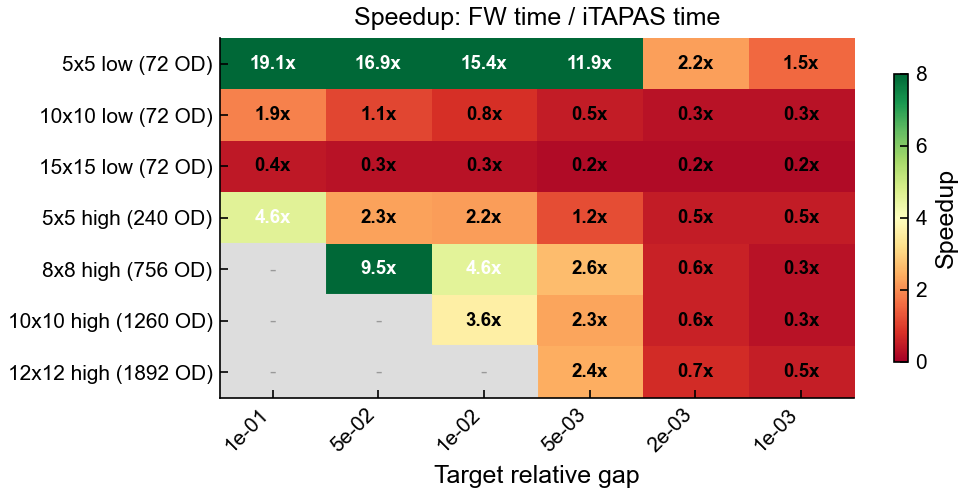

In [13]:
# ヒートマップ用のピボットテーブル作成
labels = list(all_logs.keys())
pivot = df_grid_ttg.pivot(index='scenario', columns='target_gap', values='speedup')
pivot = pivot.reindex(labels)  # シナリオ順を維持

fig, ax = plt.subplots(figsize=(7.0, 3.5))

# NaN をマスクしてプロット
data_arr = pivot.values.astype(float)
mask = np.isnan(data_arr)

im = ax.imshow(data_arr, aspect='auto', cmap='RdYlGn', vmin=0, vmax=8)

# NaN セルを灰色で塗る
for i in range(data_arr.shape[0]):
    for j in range(data_arr.shape[1]):
        if mask[i, j]:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                        fill=True, color='#DDDDDD'))
            ax.text(j, i, '-', ha='center', va='center', fontsize=9, color='#999999')
        else:
            val = data_arr[i, j]
            color = 'white' if val > 4 else 'black'
            ax.text(j, i, f'{val:.1f}x', ha='center', va='center',
                    fontsize=9, fontweight='bold', color=color)

ax.set_xticks(range(len(target_gaps)))
ax.set_xticklabels([f'{g:.0e}' for g in target_gaps], rotation=45, ha='right')
ax.set_yticks(range(len(labels)))
# ラベルにOD対数を付記
ylabels = [f"{l} ({all_logs[l]['info']['od_pairs']} OD)" for l in labels]
ax.set_yticklabels(ylabels)
ax.set_xlabel("Target relative gap")
ax.set_title("Speedup: FW time / iTAPAS time")

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Speedup')

plt.tight_layout()
plt.show()

## 3. まとめ

In [14]:
# Sioux Falls + Grid 全体のサマリ
print("="*70)
print("同一精度到達時間の比較 (全シナリオ)")
print("="*70)

# Sioux Falls
print("\n【Sioux Falls (24N, 76L, 528OD)】")
sf_sub = df_ttg.dropna(subset=['speedup'])
print(f"  目標精度 1e-2 → 5e-4 で速度比 {sf_sub['speedup'].min():.1f}x ~ {sf_sub['speedup'].max():.1f}x")

# Grid サマリ
print("\n【Grid ネットワーク】")
for label in all_logs:
    info = all_logs[label]['info']
    sub = df_grid_ttg[(df_grid_ttg['scenario'] == label) & df_grid_ttg['speedup'].notna()]
    if len(sub) > 0:
        sp_min = sub['speedup'].min()
        sp_max = sub['speedup'].max()
        # FW未到達だがiTAPAS到達のケース
        fw_fail = df_grid_ttg[(df_grid_ttg['scenario'] == label) &
                              df_grid_ttg['FW [s]'].isna() &
                              df_grid_ttg['iTAPAS [s]'].notna()]
        extra = f" (+{len(fw_fail)} levels FW未到達)" if len(fw_fail) > 0 else ""
        print(f"  {label:12s} ({info['od_pairs']:>4d}OD): {sp_min:.1f}x ~ {sp_max:.1f}x{extra}")
    else:
        print(f"  {label:12s}: 共通到達精度なし")

同一精度到達時間の比較 (全シナリオ)

【Sioux Falls (24N, 76L, 528OD)】
  目標精度 1e-2 → 5e-4 で速度比 1.0x ~ 19.6x

【Grid ネットワーク】
  5x5 low      (  72OD): 1.5x ~ 19.1x
  10x10 low    (  72OD): 0.3x ~ 1.9x
  15x15 low    (  72OD): 0.2x ~ 0.4x
  5x5 high     ( 240OD): 0.5x ~ 4.6x
  8x8 high     ( 756OD): 0.3x ~ 9.5x (+1 levels FW未到達)
  10x10 high   (1260OD): 0.3x ~ 3.6x (+2 levels FW未到達)
  12x12 high   (1892OD): 0.5x ~ 2.4x (+3 levels FW未到達)
